# Model Summary

- **Authored by:** Matheus Ferreira Silva 
- **GitHub:**: https://github.com/MatheusFS-dev

## 1. Imports

In [1]:
# --------------------------- Standard Libraries ---------------------------- #
from IPython.display import Image, display
# ----------------------- TensorFlow and Keras Modules ---------------------- #
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

2025-04-24 08:56:46.155328: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 08:56:46.327413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745495806.392547   18955 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745495806.411979   18955 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-24 08:56:46.563274: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## 2. Main Code

I0000 00:00:1745495809.053511   18955 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2229 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 200,   │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lidar_conv2d_0      │ (None, 20, 200,   │      2,016 │ input_layer[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lidar_batch_norm_0  │ (None, 20, 200,   │        384 │ lidar_conv2d_0[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coord_dense_0       │ (None, 128)       │        384 │ input_layer_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lidar_conv2d_1      │ (None, 20, 200,   │     14,630 │ lidar_batch_norm… │
│ (Conv2D)            │ 38)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coord_batch_norm_0  │ (None, 128)       │        512 │ coord_dense_0[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 152000)    │          0 │ lidar_conv2d_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coord_dropout_0     │ (None, 128)       │          0 │ coord_batch_norm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 152128)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ coord_dropout_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 38,945,024 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,962,952 (148.63 MB)

 Trainable params: 38,962,502 (148.63 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

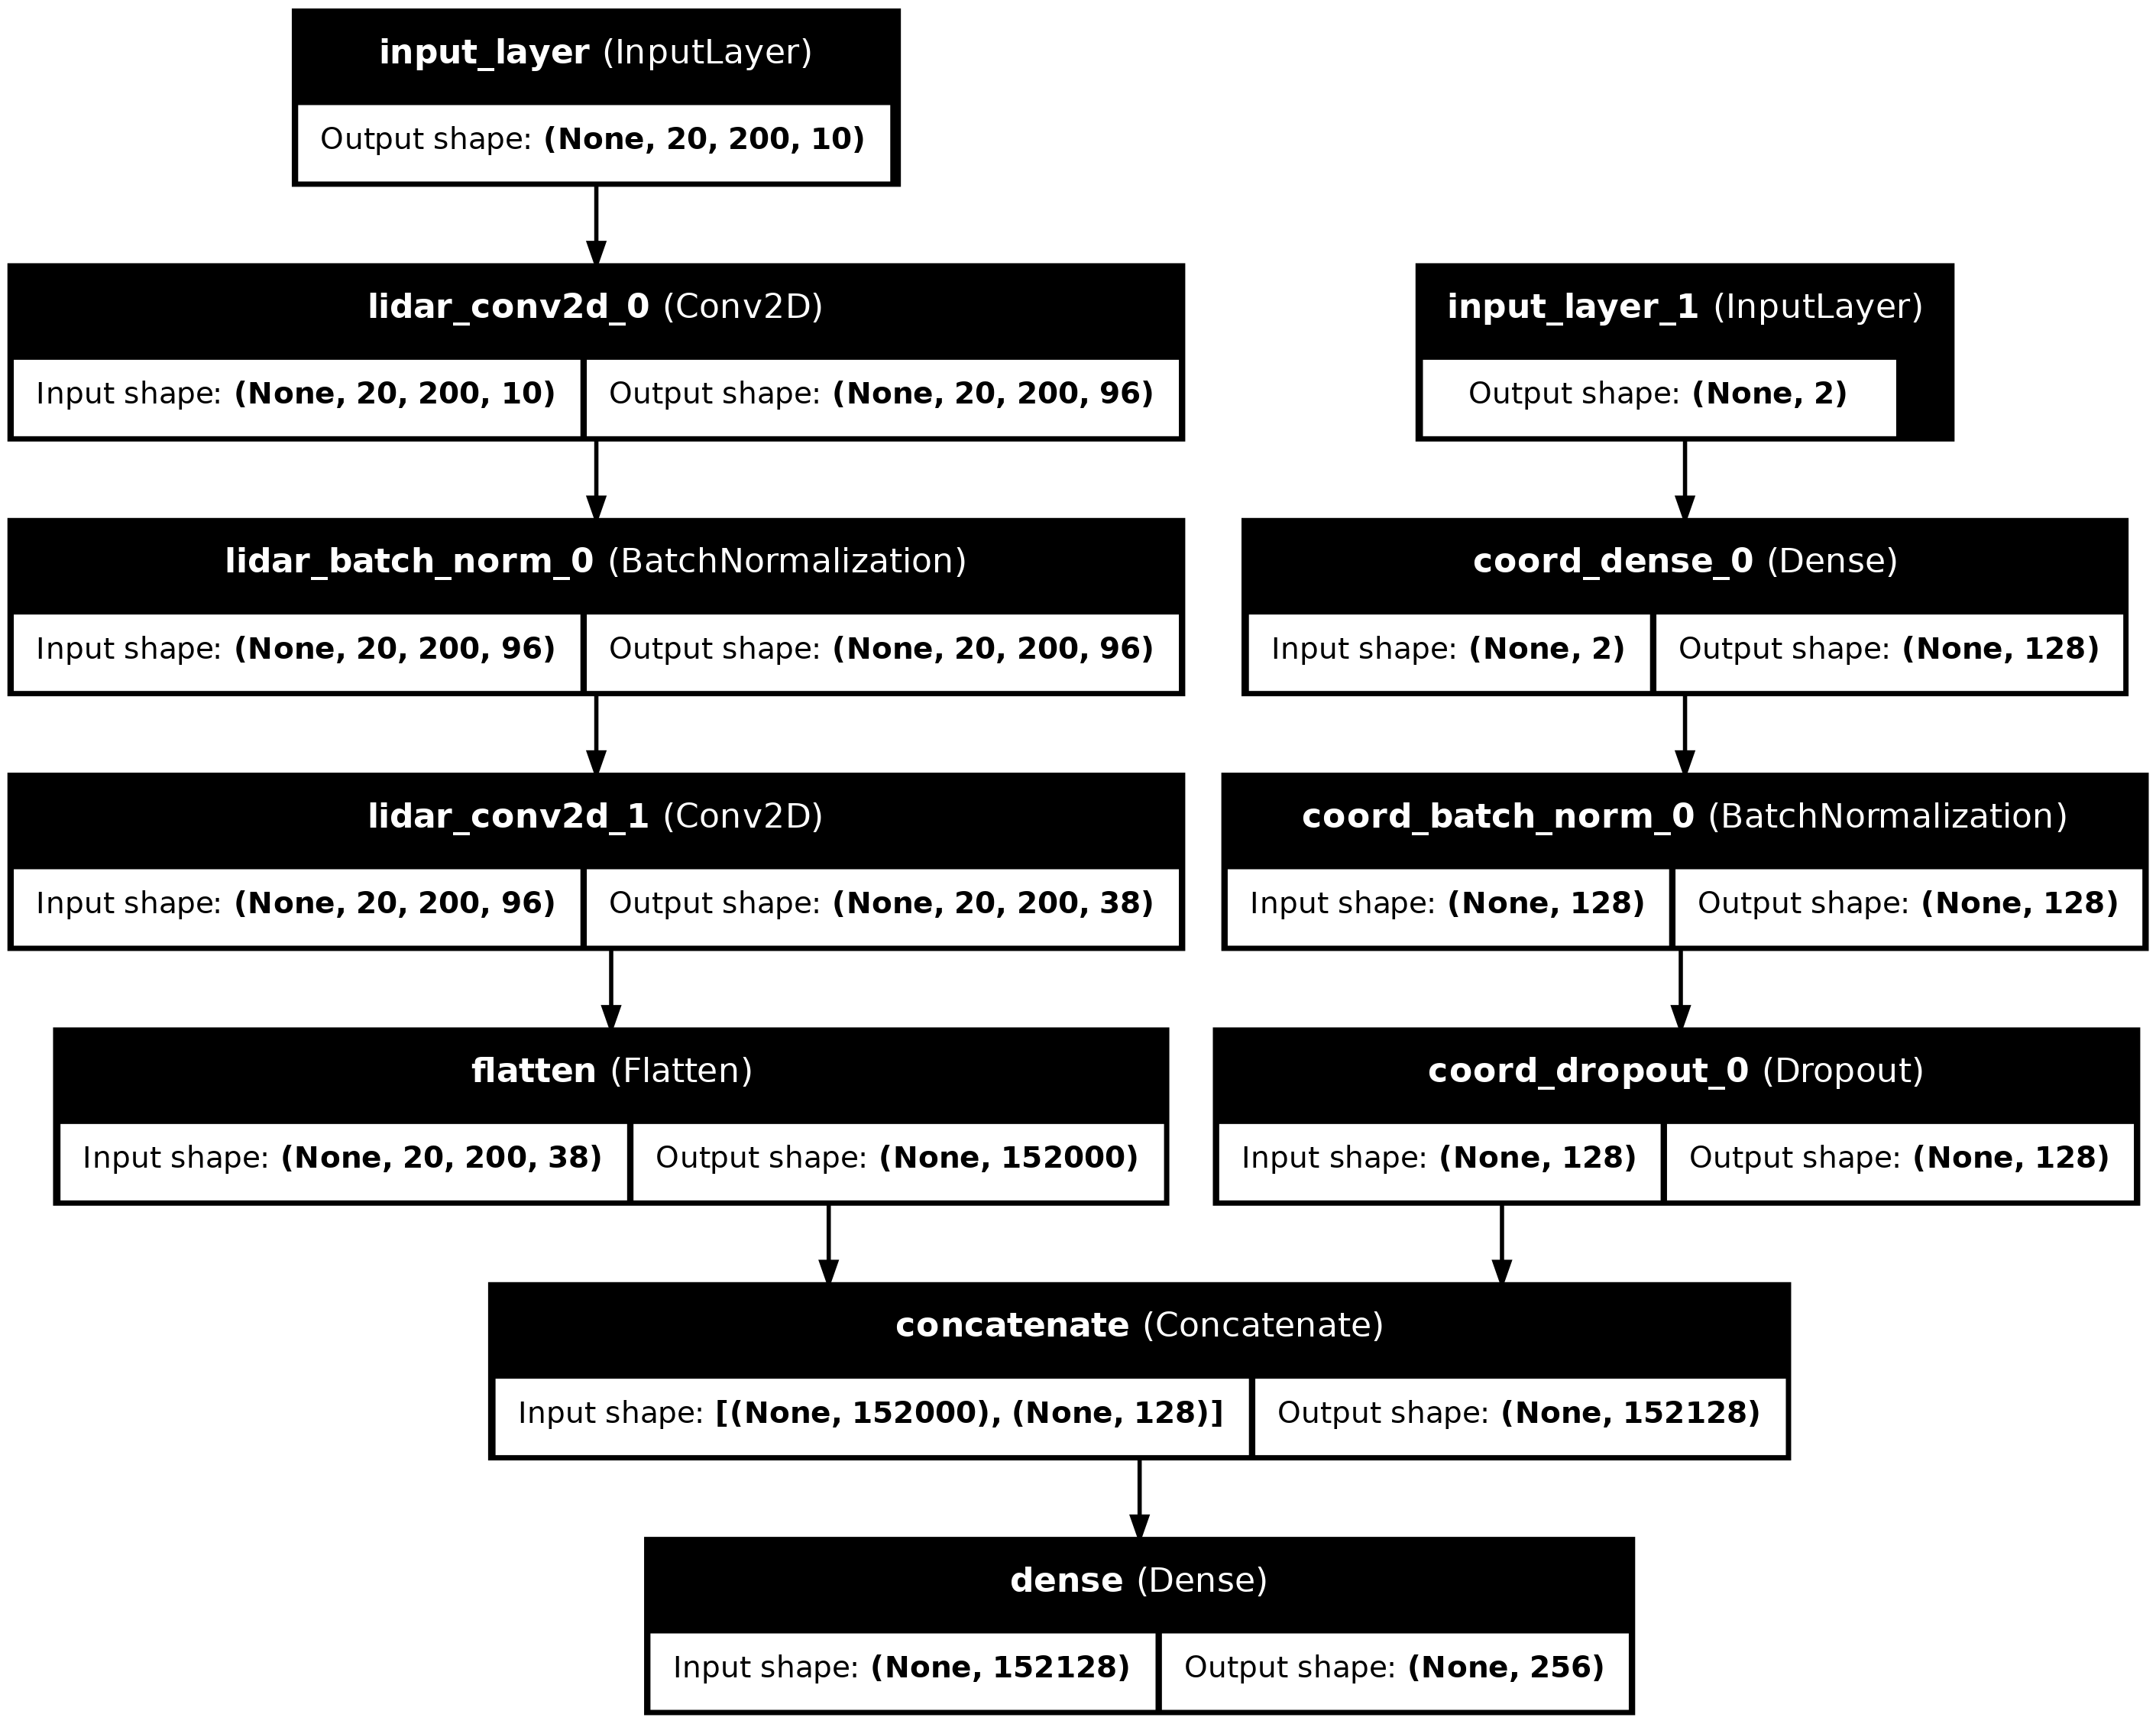

In [2]:
# Load the model
model = tf.keras.models.load_model('./results/nas_1/models/trial_19.keras')

# Show the model summary
model.summary()

# Plot the model architecture
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

# Display the model architecture image
display(Image(filename='model.png'))